In [21]:
#Fitting wCDM mock data

import numpy as np

from astropy.io import fits
from astropy.cosmology import w0waCDM
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import wCDM

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import statistics as stat

import matplotlib.image as mpimg

import pandas as pd

import scipy.stats as stats
from scipy import optimize
from scipy.stats import spearmanr
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.special import erfcinv
from scipy.special import erfinv

from nautilus import Prior
from nautilus import Sampler

from sklearn.metrics import r2_score

import corner
from corner import quantile

from anesthetic import Samples

import nautilus.sampler as ns
from nautilus import Sampler
import nautilus.sampler as ns

import camb
from camb import model, initialpower
from camb.baseconfig import CAMBError

import h5py

ns.h5py = h5py

print("Hello world")

Hello world


In [22]:
#Check all dependencies
import numpy, scipy, matplotlib, pandas, astropy, sklearn, h5py, camb, corner, anesthetic, nautilus

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("astropy:", astropy.__version__)
print("sklearn:", sklearn.__version__)
print("h5py:", h5py.__version__)
print("camb:", camb.__version__)
print("corner:", corner.__version__)
print("anesthetic:", anesthetic.__version__)
print("nautilus:", nautilus.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
astropy: 7.2.0
sklearn: 1.7.2
h5py: 3.15.1
camb: 1.6.5
corner: 2.2.3
anesthetic: 2.11.0
nautilus: 1.0.5


In [23]:
#Reading the real data CSV file
df = pd.read_csv(
    'DES-Dovekie_HD.csv',
    comment='#',
    sep=r'\s+',
    engine='python'
)

In [24]:
#Selecting only the DES, CFA3, CFA4, CSP and Foundation Sne with zHD>=0.025 and a Probability of being SN1a above 0.9
allowed = [10, 63, 64, 65, 66, 150]

filtered = df[
    (df["IDSURVEY"].isin(allowed)) &
    (df["zHD"] >= 0.025) &
    (df["PROBIA_BEAMS"] > 0.9)
]

filtered.to_csv("filtered_supernova.csv", index=False)

In [25]:
#Reading the new resulting dataset
sn_real = pd.read_csv(
    'filtered_supernova.csv',
    engine='python'
)

len(sn_real)

1687

In [26]:
#Making an array with only the redshift and only the muerr
real_z = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_z[i] = sn_real.iloc[i, 3]

real_muerr = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_muerr[i] = sn_real.iloc[i, 6]

#Isolating the MU so we can compare later on with our synthetic data
real_mu = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_mu[i] = sn_real.iloc[i, 5]
    
real_zHEL = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_zHEL[i] = sn_real.iloc[i, 4]
    
len(real_mu)

1687

In [27]:
#Functions to calculate likelihoods
def CMB_log_likelihood(CMB_model, CMB, inv_cov):
    delta = np.array([CMB_model - CMB])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def BAO_log_likelihood(BAO_model, BAO, inv_cov):
    delta = np.array([BAO_model - BAO])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def cov_log_likelihood(mu_model, mu, inv_cov):
    delta = np.array(mu_model) - np.array(mu)
    deltaT = np.transpose(delta)
    chit2 = np.sum(delta @ inv_cov @ deltaT)
    B = np.sum(delta @ inv_cov)
    C = np.sum(inv_cov)
    chi2 = chit2 - (B**2 / C) + np.log(C / (2 * np.pi))
    return -0.5*chi2

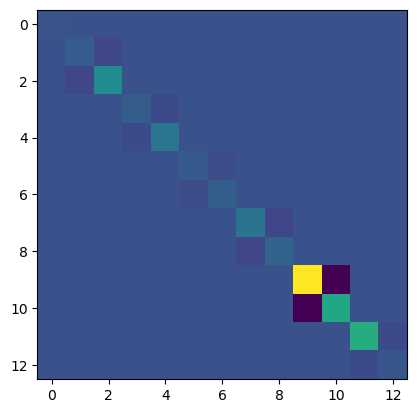

In [28]:
#Covarience matrix for BAO and CMB
corr_CMB1 = [[1, 0.46, -0.66],[0.46, 1, -0.33],[-0.66, -0.33, 1]]
corr_CMB = np.array(corr_CMB1)

sigmas = np.array([0.0046, 0.0895, 0.00015])

cov_CMB = np.diag(sigmas) @ corr_CMB @ np.diag(sigmas)

# Inverse covariance (precision matrix)
inv_CMB = np.linalg.inv(cov_CMB)

#BAO cov

zeff = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])
BAO_errors = [0.075, 0.167, 0.425, 0.177, 0.330, 0.152, 0.193, 0.318, 0.221, 0.760, 0.516, 0.531, 0.101]
BAO_sd = []

for i in range(len(BAO_errors)):
    BAO_sd.append(BAO_errors[i]**2)

BAO_cov = np.diag(BAO_sd)
BAO_corr = [-0.459, -0.404, -0.416, -0.434, -0.500, -0.431]

for i, rho in enumerate(BAO_corr):
    dm_idx = 2*i + 1   # Dm index
    dh_idx = 2*i + 2   # Dh index

    cov = rho * BAO_errors[dm_idx] * BAO_errors[dh_idx]
    BAO_cov[dm_idx, dh_idx] = cov
    BAO_cov[dh_idx, dm_idx] = cov
    
inv_BAO = np.linalg.inv(BAO_cov)

plt.imshow(BAO_cov)

cng = np.random.default_rng()
bng = np.random.default_rng()
rng = np.random.default_rng()

In [29]:
def MU(z, zHEL):
    result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
    return result

Text(0, 0.5, 'counts')

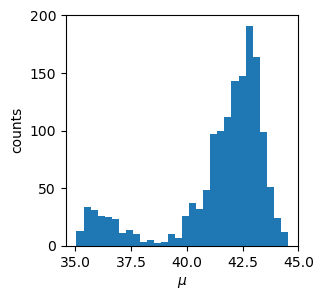

In [30]:
#Calculating one realisation of synthetic distance moduli to produce figure 2 in the paper:

ombh25 = 0.02236
omch25 = 0.1202
H05 = 68.02
zstar5 = 1089.95 #
rstar5 = 144.39 #
zdrag5 = 1059.93 #
rdrag5 = 147.05 #
w5 = -0.995
c5 = 299792.458

# Randomly sample 1500 unique entries
idx5 = np.random.choice(sn_real.shape[0], size=1500, replace=True)
random_sn5 = sn_real.iloc[idx5]

synth_z5 = np.zeros(len(random_sn5))
synth_zHEL5 = np.zeros(len(random_sn5))
    
#Randomly select 1500 redshifts
for i in range(len(random_sn5)):
    synth_z5[i] = random_sn5.iloc[i, 3]
    synth_zHEL5[i] = random_sn5.iloc[i, 4]
    
#Corresponding distance modulus and error
real_mu_corresponding_to_z5 = np.zeros(len(random_sn5))
for i in range(len(random_sn5)):
    real_mu_corresponding_to_z5[i] = random_sn5.iloc[i, 5]

real_muerr_corresponding_to_z5 = np.zeros(len(random_sn5))
for i in range(len(random_sn5)):
    real_muerr_corresponding_to_z5[i] = random_sn5.iloc[i, 6]

pars5 = camb.CAMBparams()
pars5.set_cosmology(H0=H05,
    ombh2=ombh25,
    omch2=omch25,
    omk=0)
        
pars5.set_dark_energy(
w=w5,
dark_energy_model='ppf'
)

h5 = H05 / 100.0
Om05 = (ombh25 + omch25) / h5**2
ommh25 = ombh25 + omch25

results = camb.get_background(pars5)

synth_mu5 = []
for i in range(1500):
    synth_mu5.append(MU(synth_z5[i],synth_zHEL5[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z5[i], size=None))

plt.figure(figsize=[3,3])
plt.hist(synth_mu5, bins = 30)
plt.xlabel(f"$\mu$")
plt.ylabel(f"counts")

In [31]:
#All likelyhoods and priors

def likelyhoodSN_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    #ombh2=theta['ombh2']
    omb=theta['omb']
    H0=theta['H0']
    
    #Enforcing w0+wa<0, any time this combination occurs, likelyhood returned is -infinity

    if w0 + wa >= 0:
        return -np.inf
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)

    except CAMBError:
        return -np.inf
    
#BAO likelyhood:
def likelyhoodBAO_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)
    
    except CAMBError:
        return -np.inf


def likelyhoodBAO_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf

def likelyhoodCMB_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodBAO_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#####################################################################################################################
    
#Priors for the parameter estimation
#w0waCDM
prior_w0waCDM_est = Prior()
prior_w0waCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_w0waCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_w0waCDM_est.add_parameter('wa', dist=(-3,+2))
prior_w0waCDM_est.add_parameter('w0', dist=(-3, -0.4))
prior_w0waCDM_est.add_parameter('H0', dist=(+55, +91))

#wCDM
prior_wCDM_est = Prior()
prior_wCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_wCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_wCDM_est.add_parameter('w0', dist=(-3,-0.4))
prior_wCDM_est.add_parameter('H0', dist=(+55, +91))

#LCDM
prior_LCDM_est = Prior()
prior_LCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_LCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_LCDM_est.add_parameter('H0', dist=(+55, +91))

#####################################################################################################################

#Likelihoods when combining probes
def likelyhoodSN_CMB_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta)

def likelyhoodSN_CMB_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

def likelyhoodSN_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

#######################################

def likelyhoodSN_CMB_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta)

def likelyhoodSN_CMB_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta) + likelyhoodBAO_wCDM(theta)

def likelyhoodSN_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodBAO_wCDM(theta)

#######################################

def likelyhoodSN_CMB_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta)

def likelyhoodSN_CMB_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta) + likelyhoodBAO_LCDM(theta)

def likelyhoodSN_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodBAO_LCDM(theta)

In [32]:
#Rerunning the sampler for the real data with no supernova covariances for comparison. Make sure you run
#these in the real no covmat notebook FIRST and set the path to the output files in the samplers below

#The samplers...
samplerSN_CMB_BAO_w0waCDM__est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"nocov_w0wa.h5")
samplerSN_CMB_BAO_w0waCDM__est.run(verbose=True)

#######################################

samplerSN_CMB_BAO_wCDM__est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, filepath = f"nocov_w.h5")
samplerSN_CMB_BAO_wCDM__est.run(verbose=True)

#######################################

samplerSN_CMB_BAO_LCDM__est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"nocov_L.h5")
samplerSN_CMB_BAO_LCDM__est.run(verbose=True)

####################################### extracting all the points, weights and likelihoods and posterior covariance matrix

#for w0waCDM
points_SN_CMB_BAO_w0waCDM_real, log_w_SN_CMB_BAO_w0waCDM_real, log_l_SN_CMB_BAO_w0waCDM_real = samplerSN_CMB_BAO_w0waCDM__est.posterior()
weights_SN_CMB_BAO_w0waCDM_real = np.exp(log_w_SN_CMB_BAO_w0waCDM_real)

labels_SN_CMB_BAO_w0waCDM_real = list(prior_w0waCDM_est.keys)

samples_SN_CMB_BAO_w0waCDM_real = Samples(points_SN_CMB_BAO_w0waCDM_real, 
                  weights=weights_SN_CMB_BAO_w0waCDM_real,
                  columns=labels_SN_CMB_BAO_w0waCDM_real)
cov_w0wa_real = samples_SN_CMB_BAO_w0waCDM_real.cov()

#######################################

#for wCDM
points_SN_CMB_BAO_wCDM_real, log_w_SN_CMB_BAO_wCDM_real, log_l_SN_CMB_BAO_wCDM_real = samplerSN_CMB_BAO_wCDM__est.posterior()
weights_SN_CMB_BAO_wCDM_real = np.exp(log_w_SN_CMB_BAO_wCDM_real)

labels_SN_CMB_BAO_wCDM_real = list(prior_wCDM_est.keys)

samples_SN_CMB_BAO_wCDM_real = Samples(points_SN_CMB_BAO_wCDM_real, 
                  weights=weights_SN_CMB_BAO_wCDM_real,
                  columns=labels_SN_CMB_BAO_wCDM_real)
cov_w_real = samples_SN_CMB_BAO_wCDM_real.cov()

#######################################

#for LCDM
points_SN_CMB_BAO_LCDM_real, log_w_SN_CMB_BAO_LCDM_real, log_l_SN_CMB_BAO_LCDM_real = samplerSN_CMB_BAO_LCDM__est.posterior()
weights_SN_CMB_BAO_LCDM_real = np.exp(log_w_SN_CMB_BAO_LCDM_real)

labels_SN_CMB_BAO_LCDM_real = list(prior_LCDM_est.keys)

samples_SN_CMB_BAO_LCDM_real = Samples(points_SN_CMB_BAO_LCDM_real, 
                  weights=weights_SN_CMB_BAO_LCDM_real,
                  columns=labels_SN_CMB_BAO_LCDM_real)
cov_L_real = samples_SN_CMB_BAO_LCDM_real.cov()

#For the best-fit parameter vectors for tension calculations later

data_w0wa_real = np.zeros(5)

for i, p in enumerate(prior_w0waCDM_est.keys):
    data_w0wa_real[i] = corner.quantile(points_SN_CMB_BAO_w0waCDM_real[:, i], [0.5], weights=weights_SN_CMB_BAO_w0waCDM_real)[0]
    print(f"{p} median = {data_w0wa_real[i]:.5f}")
    
data_w_real = np.zeros(4)

for i, p in enumerate(prior_wCDM_est.keys):
    data_w_real[i] = corner.quantile(points_SN_CMB_BAO_wCDM_real[:, i], [0.5], weights=weights_SN_CMB_BAO_wCDM_real)[0]
    print(f"{p} median = {data_w_real[i]:.5f}")
    
data_L_real = np.zeros(3)

for i, p in enumerate(prior_LCDM_est.keys):
    data_L_real[i] = corner.quantile(points_SN_CMB_BAO_LCDM_real[:, i], [0.5], weights=weights_SN_CMB_BAO_LCDM_real)[0]
    print(f"{p} median = {data_L_real[i]:.5f}")

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39200    | N/A    | 10050 | -834.62  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 32     | 1        | 4        | 68400    | N/A    | 14709 | -842.48  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30400    | N/A    | 10007 | -843.09  
omb median = 0.04954
Om0 median = 0.31841
wa median = -0.91107
w0 median = -0.75581
H0 median = 67.26946
omb median = 0.05012
Om0 median = 0.31299
w0 median = -0.94509
H0 median = 67.19569
omb median = 0.04840
Om0 median = 0.30700
H0 median = 6

In [33]:
#And also defining a function to calculate tension with mahalanobis distance
def tension(mu1, cov1, mu2, cov2):
    delta = np.array(mu1) - np.array(mu2)
    cov = np.array(cov1) + np.array(cov2)
    inv_cov = np.linalg.inv(cov)
    d2 = delta.T @ inv_cov @ delta
    dof = len(delta)
    PTE = chi2.sf(d2, dof)
    print("d2 =", d2)
    print("PTE =", PTE)
    return np.sqrt(2) * erfinv(1 - PTE)

In [34]:
#50 Realisations of wCDM mock data with w0waCDM, wCDM and LCDM models fit.

ombh2 = 0.02236
omch2 = 0.1202
H0 = 68.02
zstar = 1089.95 #
rstar = 144.39 #
zdrag = 1059.93 #
rdrag = 147.05 #
w = -0.995
Om0 = 0.305
c = 299792.458

#counters for incidences of spurious mimicky set to 0
w0wa_tension_count = 0
w_tension_count = 0
L_tension_count = 0
full_tension_count = 0

#Arrays to store best fit parameters in each realisation
#w0waCDM
W0 = np.zeros(50)
W0err = np.zeros((50,2))
WA = np.zeros(50)
WAerr = np.zeros((50,2))
HUBwaw0 = np.zeros(50)
HUBwaw0err = np.zeros((50,2))
Om0waw0 = np.zeros(50)
Om0waw0err = np.zeros((50,2))
ombwaw0 = np.zeros(50)

#wCDM
W = np.zeros(50)
Werr = np.zeros((50,2))
HUBw = np.zeros(50)
HUBwerr = np.zeros((50,2))
Om0w = np.zeros(50)
Om0werr = np.zeros((50,2))
ombw = np.zeros(50)

#LCDM
HUBL = np.zeros(50)
HUBLerr = np.zeros((50,2))
Om0L = np.zeros(50)
Om0Lerr = np.zeros((50,2))
ombL = np.zeros(50)

#Storing evidences for each model each realisation
ev_w0wa = np.zeros(50)
ev_w = np.zeros(50)
ev_L = np.zeros(50)

#Coverage for 0, 20, 40, 60, 80, 100 regions for each parameter
pipeline_checkw0 = np.zeros(6)
pipeline_checkOm0 = np.zeros(6)
pipeline_checkH = np.zeros(6)

for u in range(50):
    
    # Randomly sample 1500 unique entries
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    
    #Randomly select 1500 redshifts
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    #Corresponding distance modulus and error
    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6]
        
    #Make diagonal SN covmat with random errors
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)
        
    #Producing synthetic CMB data

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    #Add noise to each point
    CMB_synth = CMB_theory + noise_CMB

    #Now BAO

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    #Add noise to each point
    BAO_synth = BAO_theory + noise_BAO

    #Now SN with noise added to each point

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    #run samplers to fit w0waCDM, wCDM and LCDM
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"correct__Nooisyw_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"correct__Nooisyw_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"correct__Nooisyw_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    #Extract points, log weights, and log likelihoods
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    #Exponentiate the weights, and isolate the points for each parameter
    #for w0waCDM
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    labels_SN_CMB_BAO_w0waCDM_est = list(prior_w0waCDM_est.keys)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    #Extract the posterior covariance
    samples_SN_CMB_BAO_w0waCDM_est = Samples(points_SN_CMB_BAO_w0waCDM_est, 
                  weights=weights_SN_CMB_BAO_w0waCDM_est,
                  columns=labels_SN_CMB_BAO_w0waCDM_est)
    cov_SN_CMB_BAO_w0waCDM_est = samples_SN_CMB_BAO_w0waCDM_est.cov()
    
    #for wCDM
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    labels_SN_CMB_BAO_wCDM_est = list(prior_wCDM_est.keys)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    #Extract the posterior covariance
    samples_SN_CMB_BAO_wCDM_est = Samples(points_SN_CMB_BAO_wCDM_est, 
                  weights=weights_SN_CMB_BAO_wCDM_est,
                  columns=labels_SN_CMB_BAO_wCDM_est)
    cov_SN_CMB_BAO_wCDM_est = samples_SN_CMB_BAO_wCDM_est.cov()
    
    #for LCDM
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    labels_SN_CMB_BAO_LCDM_est = list(prior_LCDM_est.keys)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]
    
    #Extract the posterior covariance
    samples_SN_CMB_BAO_LCDM_est = Samples(points_SN_CMB_BAO_LCDM_est, 
                  weights=weights_SN_CMB_BAO_LCDM_est,
                  columns=labels_SN_CMB_BAO_LCDM_est)
    cov_SN_CMB_BAO_LCDM_est = samples_SN_CMB_BAO_LCDM_est.cov()
    
    #Extract the quantiles for each parameter
    #for w0waCDM
    w0wa_q16w0, w0wa_q50w0, w0wa_q8w0 = quantile(w0_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q16wa, w0wa_q50wa, w0wa_q8wa = quantile(wa_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q16Om0, w0wa_q50Om0, w0wa_q8Om0 = quantile(Om0_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q16H, w0wa_q50H, w0wa_q8H = quantile(H_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q16omb, w0wa_q50omb, w0wa_q8omb = quantile(omb_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    #for wCDM
    #Extra quantiles for the pipeline check
    w_q10w02, w_q16w02, w_q20w02, w_q30w02, w_q40w02, w_q50w02, w_q60w02, w_q70w02, w_q80w02, w_q8w02, w_q90w02 = quantile(w02_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q10Om02, w_q16Om02, w_q20Om02, w_q30Om02, w_q40Om02, w_q50Om02, w_q60Om02, w_q70Om02, w_q80Om02, w_q8Om02, w_q90Om02 = quantile(Om02_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q10H2, w_q16H2, w_q20H2, w_q30H2, w_q40H2, w_q50H2, w_q60H2, w_q70H2, w_q80H2, w_q8H2, w_q90H2 = quantile(H2_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q10omb2, w_q16omb2, w_q20omb2, w_q30omb2, w_q40omb2, w_q50omb2, w_q60omb2, w_q70omb2, w_q80omb2, w_q8omb2, w_q90omb2 = quantile(omb2_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_wCDM_est)
    
    #for LCDM
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    #Extract evidence for each model
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    #Input medians and errors into the arrays defined above for each parameter
    #for w0waCDM
    W0[u] = w0wa_q50w0
    W0err[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA[u] = w0wa_q50wa
    WAerr[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw0[u] = w0wa_q50H
    HUBwaw0err[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw0[u] = w0wa_q50Om0
    Om0waw0err[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw0[u] = w0wa_q50omb
    
    #Toggle number at the end of if statements to change significance level we want to count indidences at.
    #Counting number of times wCDM data can reproduce w0waCDM best fit parameters from the real no covmat data
    dataw0wa = np.array((ombwaw0[u], Om0waw0[u], WA[u], W0[u], HUBwaw0[u]))
    if tension(dataw0wa, cov_SN_CMB_BAO_w0waCDM_est, data_w0wa_real, cov_w0wa_real) < 1:
        w0wa_tension_count += 1

    #for wCDM
    W[u] = w_q50w02
    Werr[u,0] = w_q50w02 - w_q16w02
    Werr[u,1] = w_q8w02 - w_q50w02
    HUBw[u] = w_q50H2
    HUBwerr[u,0] = w_q50H2 - w_q16H2
    HUBwerr[u,1] = w_q8H2 - w_q50H2
    Om0w[u] = w_q50Om02
    Om0werr[u,0] = w_q50Om02 - w_q16Om02
    Om0werr[u,1] = w_q8Om02 - w_q50Om02
    ombw[u] = w_q50omb2
    
    #Counting number of times wCDM data can reproduce wCDM best fit parameters from the real no covmat data
    dataw = np.array((ombw[u], Om0w[u], W[u], HUBw[u]))
    if tension(dataw, cov_SN_CMB_BAO_wCDM_est, data_w_real, cov_w_real) < 1:
        w_tension_count += 1

    #for LCDM
    HUBL[u] = L_q50H3
    HUBLerr[u,0] = L_q50H3 - L_q16H3
    HUBLerr[u,1] = L_q8H3 - L_q50H3
    Om0L[u] = L_q50Om03
    Om0Lerr[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr[u,1] = L_q8Om03 - L_q50Om03
    ombL[u] = L_q50omb3
    
    #Counting number of times wCDM data can reproduce LCDM best fit parameters from the real no covmat data
    dataL = np.array((ombL[u], Om0L[u], HUBL[u]))
    if tension(dataL, cov_SN_CMB_BAO_LCDM_est, data_L_real, cov_L_real) < 1:
        L_tension_count += 1
        
    #Counting number of times wCDM data can reproduce ALL best fit parameters from the real no covmat data
    if tension(dataw0wa, cov_SN_CMB_BAO_w0waCDM_est, data_w0wa_real, cov_w0wa_real) < 1 and tension(dataw, cov_SN_CMB_BAO_wCDM_est, data_w_real, cov_w_real) < 1 and tension(dataL, cov_SN_CMB_BAO_LCDM_est, data_L_real, cov_L_real) < 1:
        full_tension_count += 1
    
    #Input the evidences in the arrays
    ev_w0wa[u] = log_z_w0wa
    ev_w[u] = log_z_w
    ev_L[u] = log_z_L
    
    #Coverage test for each wCDM parameter fit to the wCDM mock data
    
    #H0 check
    
    # 20%
    if w_q40H2 < H0 < w_q60H2:
        pipeline_checkH[1] += 1
    # 40%
    if w_q30H2 < H0 < w_q70H2:
        pipeline_checkH[2] += 1
    # 60%
    if w_q20H2 < H0 < w_q80H2:
        pipeline_checkH[3] += 1
    # 80%
    if w_q10H2 < H0 < w_q90H2:
        pipeline_checkH[4] += 1
    pipeline_checkH[5] += 1
        
    #Om0 check
        
    # 20%
    if w_q40Om02 < Om0 < w_q60Om02:
        pipeline_checkOm0[1] += 1
    # 40%
    if w_q30Om02 < Om0 < w_q70Om02:
        pipeline_checkOm0[2] += 1
    # 60%
    if w_q20Om02 < Om0 < w_q80Om02:
        pipeline_checkOm0[3] += 1
    # 80%
    if w_q10Om02 < Om0 < w_q90Om02:
        pipeline_checkOm0[4] += 1
    pipeline_checkOm0[5] += 1
        
    #w0 check

    # 20%
    if w_q40w02 < w < w_q60w02:
        pipeline_checkw0[1] += 1
    # 40%
    if w_q30w02 < w < w_q70w02:
        pipeline_checkw0[2] += 1
    # 60%
    if w_q20w02 < w < w_q80w02:
        pipeline_checkw0[3] += 1
    # 80%
    if w_q10w02 < w < w_q90w02:
        pipeline_checkw0[4] += 1
    pipeline_checkw0[5] += 1
    
print(f"w0wa consistent (T<1): {w0wa_tension_count}")
print(f"w consistent (T<1): {w_tension_count}")
print(f"L consistent (T<1): {L_tension_count}")
print(f"fully consistent (T<1): {full_tension_count}")

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 35     | 1        | 4        | 40100    | N/A    | 10065 | -793.71  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36400    | N/A    | 10014 | -791.72  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30200    | N/A    | 10035 | -789.62  
d2 = 16.61544662295454
PTE = 0.005289920892644731
d2 = 4.766509424947896
PTE = 0.31210471152485014
d2 = 4.681265165816195
PTE = 0.19668059641640467
d2 = 16.61544662295454
PTE = 0.005289920892644731
Starting the nautilus sampler...
Please report

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39100    | N/A    | 10076 | -759.48  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36100    | N/A    | 10084 | -757.85  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30500    | N/A    | 10009 | -753.99  
d2 = 10.28445422730048
PTE = 0.06756508106536564
d2 = 5.5157068728964
PTE = 0.23835227880395474
d2 = 2.4283147732726174
PTE = 0.4883856014945712
d2 = 10.28445422730048
PTE = 0.06756508106536564
Starting the nautilus sampler...
Please report iss

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39700    | N/A    | 10092 | -774.03  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36000    | N/A    | 10077 | -771.73  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30500    | N/A    | 10116 | -768.76  
d2 = 19.80393058768481
PTE = 0.0013601405969833771
d2 = 10.112188517432138
PTE = 0.03857969496147962
d2 = 0.3433277251990036
PTE = 0.951683944785086
d2 = 19.80393058768481
PTE = 0.0013601405969833771
Starting the nautilus sampler...
Please repo

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39200    | N/A    | 10106 | -794.92  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36100    | N/A    | 10088 | -793.13  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 25     | 1        | 4        | 30600    | N/A    | 10069 | -789.29  
d2 = 13.859245056250561
PTE = 0.016528668551037264
d2 = 8.872589052518759
PTE = 0.0643642547301918
d2 = 3.2077228817927543
PTE = 0.36069376484440485
d2 = 13.859245056250561
PTE = 0.016528668551037264
Starting the nautilus sampler...
Please repo

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39100    | N/A    | 10073 | -802.93  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36500    | N/A    | 10080 | -801.78  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30400    | N/A    | 10031 | -797.84  
d2 = 10.334594357092696
PTE = 0.06629113065231201
d2 = 6.739339491934094
PTE = 0.15032099379230657
d2 = 3.326817579183245
PTE = 0.3439275442558045
d2 = 10.334594357092696
PTE = 0.06629113065231201
Starting the nautilus sampler...
Please report 

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10061 | -769.64  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36500    | N/A    | 10020 | -767.42  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30400    | N/A    | 10019 | -765.99  
d2 = 8.443165961864992
PTE = 0.133444089092979
d2 = 2.330734568250849
PTE = 0.6751790994321595
d2 = 2.619680934818644
PTE = 0.4540496670988936
d2 = 8.443165961864992
PTE = 0.133444089092979
Starting the nautilus sampler...
Please report issues 

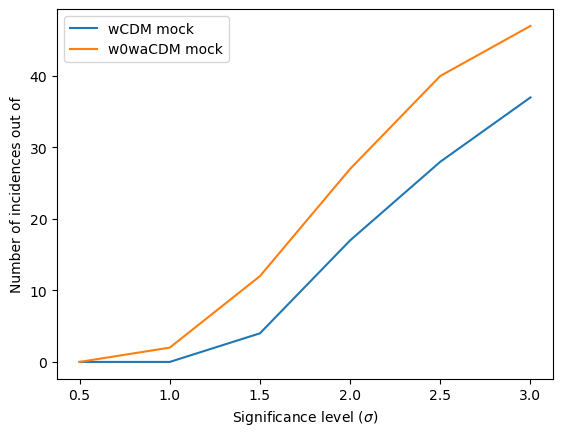

In [35]:
# Number of incidences of parameter-set agreement for all three models simultaneously. Hard coded array by toggling
# significance level in block of code above
w_incidences = [0, 0, 4, 17, 28, 37]

#incidences from w0wa_NOISY notebook
w0wa_incidences = [0, 2, 12, 27, 40, 47]
sig_levels = [0.5, 1, 1.5, 2, 2.5, 3]

plt.plot(sig_levels, w_incidences, label='wCDM mock')
plt.plot(sig_levels, w0wa_incidences, label='w0waCDM mock')

plt.xlabel(r'Significance level ($\sigma$)')
plt.ylabel('Number of incidences out of')
plt.legend()

plt.show()

In [36]:
#mean preferences for wCDM mock data
preference_w0waCDM_over_wCDM = ev_w0wa - ev_w

preference_w0waCDM_over_LCDM = ev_w0wa - ev_L

print(np.mean(preference_w0waCDM_over_LCDM))
print(np.mean(preference_w0waCDM_over_wCDM))

-5.838306800476642
-2.3406077869108026


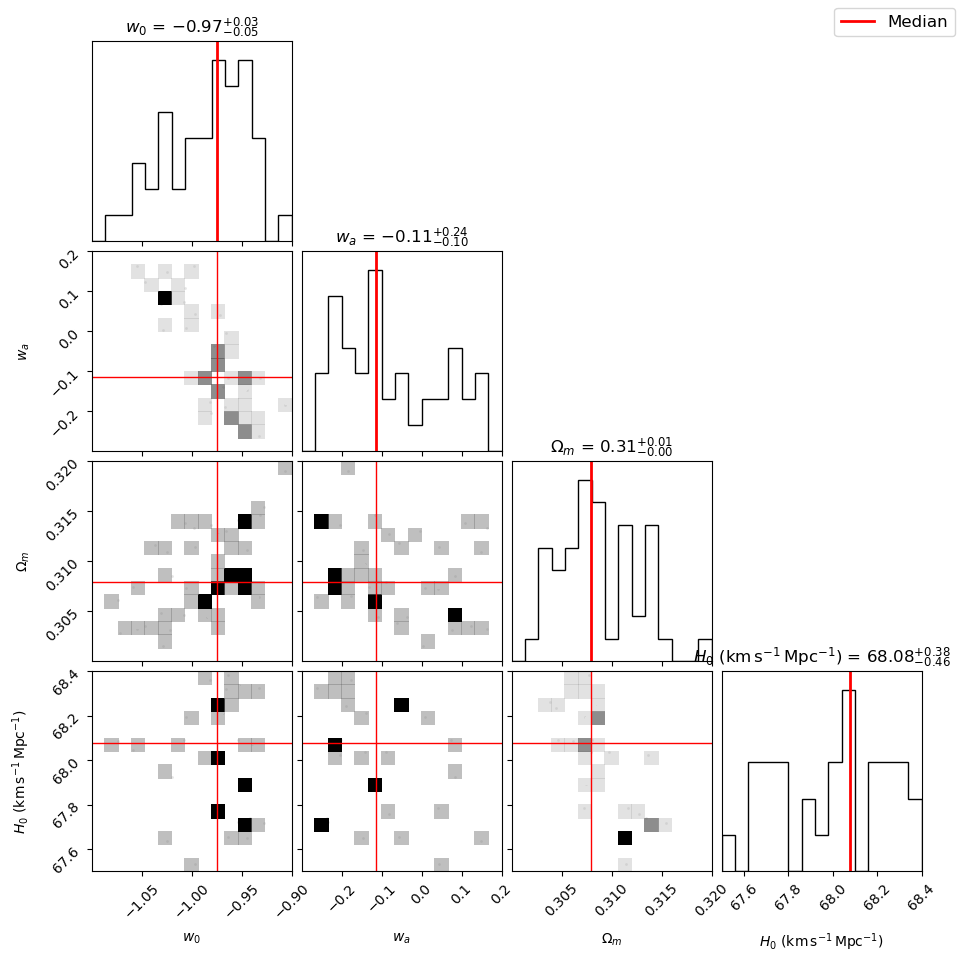

In [37]:
#Corner plot

samples_w0wa = np.vstack([
    W0,
    WA,
    Om0waw0,
    HUBwaw0,
]).T

# Median values
medianw0wa = [np.median(W0), np.median(WA), np.median(Om0waw0), np.median(HUBwaw0)]

# Plot ranges
ranges_w0wa = [
    (-1.1, -0.9),
    (-0.3, 0.2),    
    (0.3, 0.32),    
    (67.5, 68.4)   
]

labels2 =[
    r"$w_0$",
    r"$w_a$",
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

# Create corner plot
fig = corner.corner(
    samples_w0wa,
    labels=labels2,
    show_titles=True,
    range=ranges_w0wa,
    plot_datapoints=True,
    fill_contours=False,
    plot_contours=False,
    bins=15
)

# Add median lines
ndim = samples_w0wa.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(medianw0wa[i], color="red", lw=2, label="Median")

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axvline(medianw0wa[j], color="red", lw=1)
        ax.axhline(medianw0wa[i], color="red", lw=1)

# Add legend
median_line = mlines.Line2D([], [], color='red', lw=2, label='Median')
fig.legend(handles=[median_line], loc="upper right", fontsize=12)

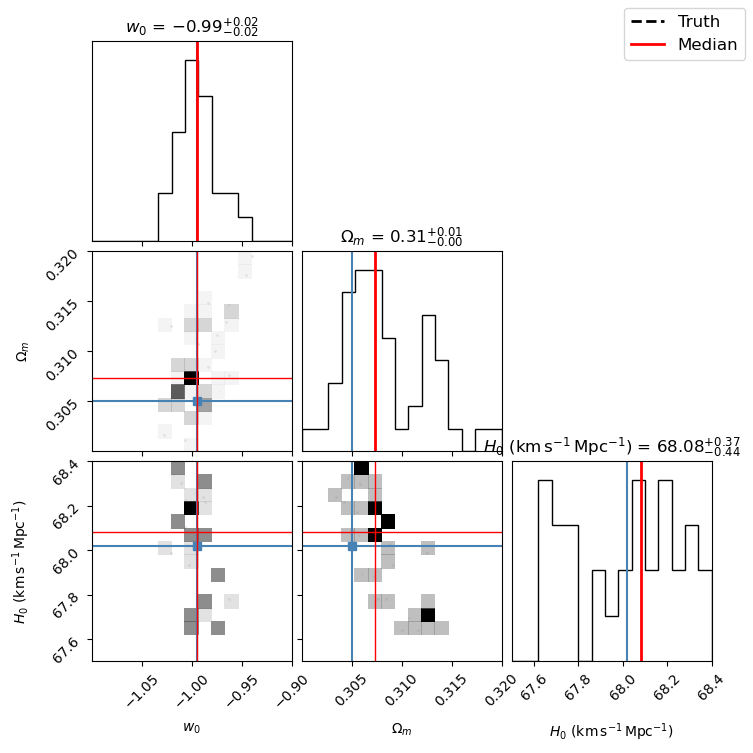

In [38]:
samples_w = np.vstack([
    W,
    Om0w,
    HUBw,
]).T 

true_vals = [-0.995, 0.305, 68.02]
medianw = [np.median(W), np.median(Om0w), np.median(HUBw)]

ranges = [
    (-1.1, -0.9),   
    (0.3, 0.32),    
    (67.5, 68.4), 
]


labels =[
    r"$w_0$",
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

fig = corner.corner(
    samples_w,
    labels=labels,
    show_titles=True,
    truths=true_vals, 
    range=ranges,
    plot_datapoints=True,
    fill_contours=False,
    plot_contours=False,
    bins=15
)

#Add median lines manually
ndim = samples_w.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(medianw[i], color="red", lw=2)

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axvline(medianw[j], color="red", lw=1)
        ax.axhline(medianw[i], color="red", lw=1)

#Add legend
truth_line = mlines.Line2D([], [], color='black', lw=2, linestyle='--', label='Truth')
median_line = mlines.Line2D([], [], color='red', lw=2, label='Median')

fig.legend(handles=[truth_line, median_line], loc="upper right", fontsize=12)

In [39]:
#Print the median parameter values for wCDM mock data
print(np.median(W0), np.std(W0))
print(np.median(WA), np.std(WA))
print(np.median(HUBwaw0), np.std(HUBwaw0))
print(np.median(Om0waw0), np.std(Om0waw0))

print(np.median(W), np.std(W))
print(np.median(HUBw), np.std(HUBw))
print(np.median(Om0w), np.std(Om0w))

print(np.median(HUBL), np.std(HUBL))
print(np.median(Om0L), np.std(Om0L))

-0.9748472921067416 0.04596603123064992
-0.11295658994549565 0.1821519675294366
68.07942653933466 0.46189105544314135
0.30798788395586246 0.004578350508519791
-0.9945446917819436 0.019464469311590633
68.0806647576595 0.45977628367370416
0.30730476728512657 0.004307828857764666
68.12424145041595 0.26135184825958485
0.3073908320495183 0.0034958147439512243


Text(0, 0.5, 'Observed Coverage Fraction')

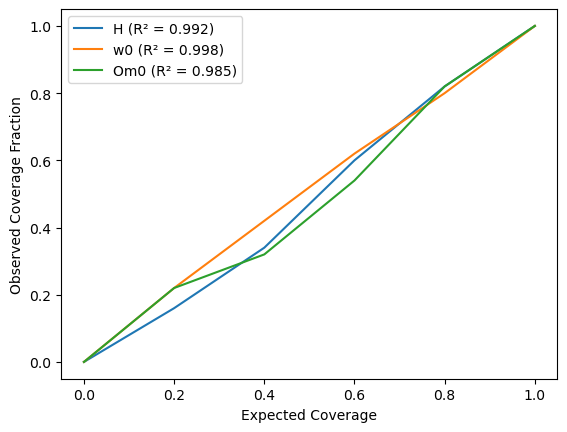

In [40]:
#Coverage test line graph

confidence_regions = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

H_obs = pipeline_checkH/50
w0_obs = pipeline_checkw0/50
Om0_obs = pipeline_checkOm0/50

r2_H = r2_score(confidence_regions, H_obs)
r2_w0 = r2_score(confidence_regions, w0_obs)
r2_Om0 = r2_score(confidence_regions, Om0_obs)

plt.plot(confidence_regions, H_obs, label=f"H (R² = {r2_H:.3f})")
plt.plot(confidence_regions, w0_obs, label=f"w0 (R² = {r2_w0:.3f})")
plt.plot(confidence_regions, Om0_obs, label=f"Om0 (R² = {r2_Om0:.3f})")

plt.legend()
plt.xlabel("Expected Coverage")
plt.ylabel("Observed Coverage Fraction")

In [41]:
#w0wa files for tension

ombh2 = 0.02236
omch2 = 0.1202
H0 = 67.47
rstar = 144.39
zdrag = 1059.93
rdrag = 147.05
w = -0.803
wa = -0.72
c = 299792.458

W01 = np.zeros(50)
W0err1 = np.zeros((50,2))
WA1 = np.zeros(50)
WAerr1 = np.zeros((50,2))
HUBwaw01 = np.zeros(50)
HUBwaw0err1 = np.zeros((50,2))
Om0waw01 = np.zeros(50)
Om0waw0err1 = np.zeros((50,2))
ombwaw01 = np.zeros(50)

W1 = np.zeros(50)
Werr1 = np.zeros((50,2))
HUBw1 = np.zeros(50)
HUBwerr1 = np.zeros((50,2))
Om0w1 = np.zeros(50)
Om0werr1 = np.zeros((50,2))
ombw1 = np.zeros(50)

HUBL1 = np.zeros(50)
HUBLerr1 = np.zeros((50,2))
Om0L1 = np.zeros(50)
Om0Lerr1 = np.zeros((50,2))
ombL1 = np.zeros(50)


for u in range(50):
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6]
        
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    wa=wa,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    CMB_synth = CMB_theory + noise_CMB

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    BAO_synth = BAO_theory + noise_BAO

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"__Nooisyw0wa_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"__Nooisyw0wa_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"__Nooisyw0wa_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    labels_SN_CMB_BAO_w0waCDM_est = list(prior_w0waCDM_est.keys)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    samples_SN_CMB_BAO_w0waCDM_est = Samples(points_SN_CMB_BAO_w0waCDM_est, 
                  weights=weights_SN_CMB_BAO_w0waCDM_est,
                  columns=labels_SN_CMB_BAO_w0waCDM_est)
    cov_SN_CMB_BAO_w0waCDM_est = samples_SN_CMB_BAO_w0waCDM_est.cov()
    
    
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    labels_SN_CMB_BAO_wCDM_est = list(prior_wCDM_est.keys)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    samples_SN_CMB_BAO_wCDM_est = Samples(points_SN_CMB_BAO_wCDM_est, 
                  weights=weights_SN_CMB_BAO_wCDM_est,
                  columns=labels_SN_CMB_BAO_wCDM_est)
    cov_SN_CMB_BAO_wCDM_est = samples_SN_CMB_BAO_wCDM_est.cov()
    
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    labels_SN_CMB_BAO_LCDM_est = list(prior_LCDM_est.keys)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]
    samples_SN_CMB_BAO_LCDM_est = Samples(points_SN_CMB_BAO_LCDM_est, 
                  weights=weights_SN_CMB_BAO_LCDM_est,
                  columns=labels_SN_CMB_BAO_LCDM_est)
    cov_SN_CMB_BAO_LCDM_est = samples_SN_CMB_BAO_LCDM_est.cov()

    
    w0wa_q10w0, w0wa_q16w0, w0wa_q20w0, w0wa_q30w0, w0wa_q40w0, w0wa_q50w0, w0wa_q60w0, w0wa_q70w0, w0wa_q80w0, w0wa_q8w0, w0wa_q90w0 = quantile(w0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10wa, w0wa_q16wa, w0wa_q20wa, w0wa_q30wa, w0wa_q40wa, w0wa_q50wa, w0wa_q60wa, w0wa_q70wa, w0wa_q80wa, w0wa_q8wa, w0wa_q90wa = quantile(wa_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10Om0, w0wa_q16Om0, w0wa_q20Om0, w0wa_q30Om0, w0wa_q40Om0, w0wa_q50Om0, w0wa_q60Om0, w0wa_q70Om0, w0wa_q80Om0, w0wa_q8Om0, w0wa_q90Om0 = quantile(Om0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10H, w0wa_q16H, w0wa_q20H, w0wa_q30H, w0wa_q40H, w0wa_q50H, w0wa_q60H, w0wa_q70H, w0wa_q80H, w0wa_q8H, w0wa_q90H = quantile(H_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10omb, w0wa_q16omb, w0wa_q20omb, w0wa_q30omb, w0wa_q40omb, w0wa_q50omb, w0wa_q60omb, w0wa_q70omb, w0wa_q80omb, w0wa_q8omb, w0wa_q90omb = quantile(omb_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    w_q16w02, w_q50w02, w_q8w02 = quantile(w02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16Om02, w_q50Om02, w_q8Om02 = quantile(Om02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16H2, w_q50H2, w_q8H2 = quantile(H2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16omb2, w_q50omb2, w_q8omb2 = quantile(omb2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    W01[u] = w0wa_q50w0
    W0err1[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err1[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA1[u] = w0wa_q50wa
    WAerr1[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr1[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw01[u] = w0wa_q50H
    HUBwaw0err1[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err1[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw01[u] = w0wa_q50Om0
    Om0waw0err1[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err1[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw01[u] = w0wa_q50omb

    W1[u] = w_q50w02
    Werr1[u,0] = w_q50w02 - w_q16w02
    Werr1[u,1] = w_q8w02 - w_q50w02
    HUBw1[u] = w_q50H2
    HUBwerr1[u,0] = w_q50H2 - w_q16H2
    HUBwerr1[u,1] = w_q8H2 - w_q50H2
    Om0w1[u] = w_q50Om02
    Om0werr1[u,0] = w_q50Om02 - w_q16Om02
    Om0werr1[u,1] = w_q8Om02 - w_q50Om02
    ombw1[u] = w_q50omb2

    HUBL1[u] = L_q50H3
    HUBLerr1[u,0] = L_q50H3 - L_q16H3
    HUBLerr1[u,1] = L_q8H3 - L_q50H3
    Om0L1[u] = L_q50Om03
    Om0Lerr1[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr1[u,1] = L_q8Om03 - L_q50Om03
    ombL1[u] = L_q50omb3

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39000    | N/A    | 10071 | -782.05  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36400    | N/A    | 10088 | -795.42  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30700    | N/A    | 10112 | -796.44  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39700    | N/A    | 10111 | -8

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39000    | N/A    | 10047 | -769.98  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36300    | N/A    | 10079 | -774.86  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30300    | N/A    | 10061 | -774.91  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39300    | N/A    | 10080 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39100    | N/A    | 10016 | -729.98  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36400    | N/A    | 10031 | -731.13  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30400    | N/A    | 10088 | -733.54  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39500    | N/A    | 10092 | -8

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10073 | -795.54  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 37000    | N/A    | 10125 | -801.08  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30800    | N/A    | 10119 | -804.81  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39300    | N/A    | 10093 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39100    | N/A    | 10024 | -780.30  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36000    | N/A    | 10027 | -788.15  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30300    | N/A    | 10001 | -784.89  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39400    | N/A    | 10102 | -7

In [44]:
# w0waCDM median values
print(np.median(W01))
print(np.median(WA1))
print(np.median(HUBwaw01))
print(np.median(Om0waw01))
print(np.median(ombwaw01))

print(np.median(W1))
print(np.median(HUBw1))
print(np.median(Om0w1))
print(np.median(ombw1))

print(np.median(HUBL1))
print(np.median(Om0L1))
print(np.median(ombL1))

-0.8027047413001778
-0.6759115521767847
67.47958744560597
0.3131746816193052
0.04911780795358677
-0.9541597524706782
67.45014734369317
0.3084992642500838
0.049492382865053156
68.32802587343465
0.30264707521308654
0.048028631940663646


In [45]:
#w0waCDM
# w0waCDM parameter matrix
params_w0wa1 = np.vstack([
    ombwaw01,
    W01,
    WA1,
    HUBwaw01,
    Om0waw01
]).T

# wCDM parameter matrix
params_w1 = np.vstack([
    ombw1,
    W1,
    HUBw1,
    Om0w1
]).T

# LCDM parameter matrix
params_L1 = np.vstack([
    ombL1,
    HUBL1,
    Om0L1
]).T

# w0waCDM covariance matrices for 50 realisations
w0wa_cov_w0wa = np.cov(params_w0wa1, rowvar=False)
w0wa_cov_w = np.cov(params_w1, rowvar=False)
w0wa_cov_L = np.cov(params_L1, rowvar=False)


#wCDM
# w0waCDM parameter matrix
params_w0wa = np.vstack([
    ombwaw0,
    W0,
    WA,
    HUBwaw0,
    Om0waw0
]).T

# wCDM parameter matrix
params_w = np.vstack([
    ombw,
    W,
    HUBw,
    Om0w
]).T

# LCDM parameter matrix
params_L = np.vstack([
    ombL,
    HUBL,
    Om0L
]).T
# w0waCDM covariance matrices for 50 realisations
w_cov_w0wa = np.cov(params_w0wa, rowvar=False)
w_cov_w = np.cov(params_w, rowvar=False)
w_cov_L = np.cov(params_L, rowvar=False)

In [46]:
# Mahalanobis distance between w0waCDM and wCDM 50 realisations

w0wadatavec_w0wa = np.array((np.median(ombwaw01), np.median(W01), np.median(WA1), np.median(HUBwaw01), np.median(Om0waw01)))
w0wadatavec_w = np.array((np.median(ombw1), np.median(W1), np.median(HUBw1), np.median(Om0w1)))
w0wadatavec_L = np.array((np.median(ombL1), np.median(HUBL1), np.median(Om0L1)))
                            
wdatavec_w0wa = np.array((np.median(ombwaw0), np.median(W0), np.median(WA), np.median(HUBwaw0), np.median(Om0waw0)))
wdatavec_w = np.array((np.median(ombw), np.median(W), np.median(HUBw), np.median(Om0w)))
wdatavec_L = np.array((np.median(ombL), np.median(HUBL), np.median(Om0L)))
                         
w0wa_tension = tension(w0wadatavec_w0wa, w0wa_cov_w0wa, wdatavec_w0wa, w_cov_w0wa)
w_tension = tension(w0wadatavec_w, w0wa_cov_w, wdatavec_w, w_cov_w)
L_tension = tension(w0wadatavec_L, w0wa_cov_L, wdatavec_L, w_cov_L)

print(w0wa_tension, w_tension, L_tension)

d2 = 8.270141957088182
PTE = 0.1419625955269107
d2 = 12.7207462793808
PTE = 0.012724035566021917
d2 = 10.514529618507652
PTE = 0.014662657604606102
1.4685215920380024 2.491401184140467 2.4406056193481414
